In [1]:
import pandas as pd

RAW_PATH = "BankChurners.csv"          
OUT_PATH = "BankChurners_clean.csv"  

df = pd.read_csv(RAW_PATH)

print("Shape (rows, cols):", df.shape)
print("")
display(df.dtypes)
print("")
df.info()


Shape (rows, cols): (10127, 23)



CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                          

In [2]:
#Drop unnecessary attributes
nb_cols = ["Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
           "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"]
df = df.drop(columns=nb_cols, errors="ignore")
df.head(3)
print("Shape after dropping (rows, cols):", df.shape)

Shape after dropping (rows, cols): (10127, 21)


In [3]:
#check n/a
print("Missing Rows: ", df.isna().sum())

Missing Rows:  CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


No missing value.

In [4]:
#check duplicated rows
print("Duplicated Rows: ", df.duplicated().sum())

Duplicated Rows:  0


ATTRITION FLAG DISTRIBUTION

Value Counts:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Percentages:
  Existing Customer: 83.93%
  Attrited Customer: 16.07%


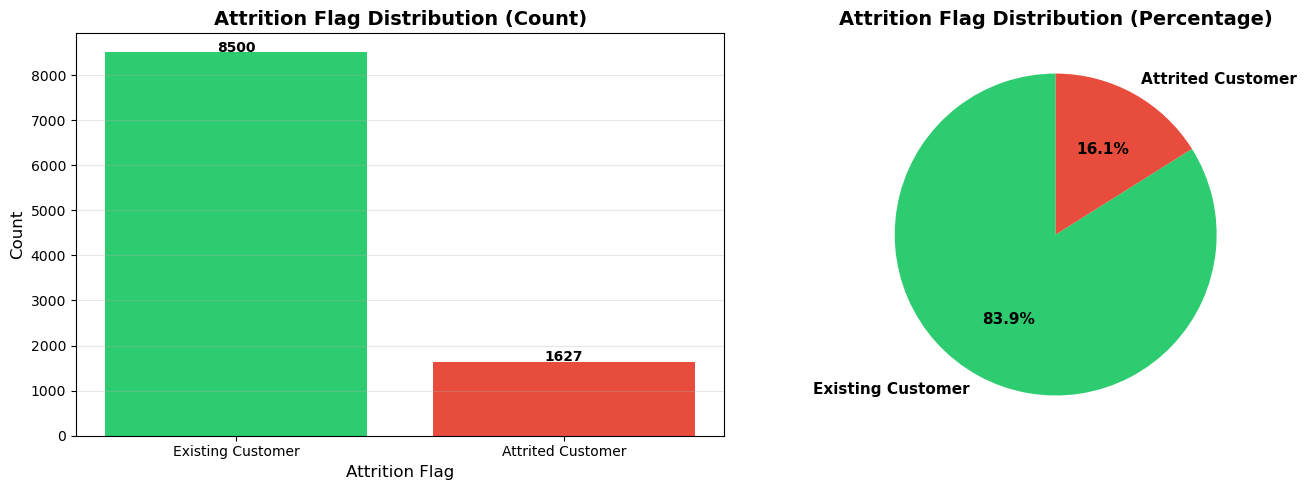

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print Attrition Flag Distribution
print("=" * 60)
print("ATTRITION FLAG DISTRIBUTION")
print("=" * 60)

# Value counts
attrition_counts = df['Attrition_Flag'].value_counts()
attrition_pct = df['Attrition_Flag'].value_counts(normalize=True) * 100

print("\nValue Counts:")
print(attrition_counts)
print("\nPercentages:")
for flag, pct in attrition_pct.items():
    print(f"  {flag}: {pct:.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(attrition_counts.index, attrition_counts.values, color=colors)
axes[0].set_title('Attrition Flag Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Attrition Flag', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Attrition Flag Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 60)

## Dataset Balancing
Using SMOTE


Before SMOTE:
  Total samples: 10127
  {'Existing Customer': 8500, 'Attrited Customer': 1627}

After SMOTE:
  Total samples: 17000
  {'Existing Customer': 8500, 'Attrited Customer': 8500}

Balance improvement:
  Before: 19.14% (Minority / Majority)
  After: 100.00% (Minority / Majority)


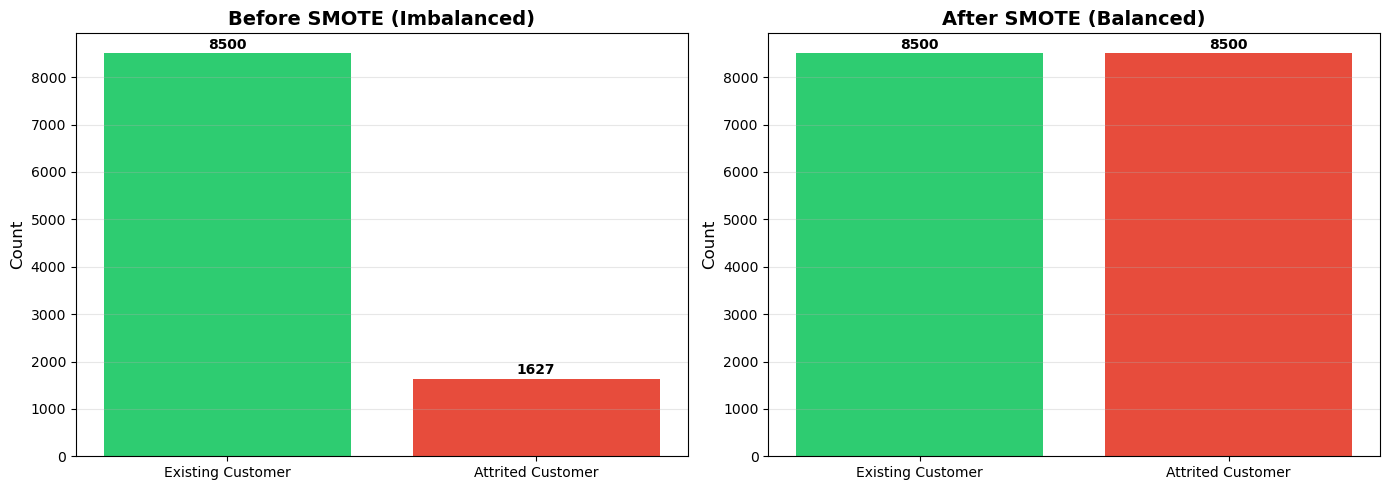

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Create a copy of the dataframe for SMOTE
df_smote = df.copy()

# Encode categorical variables
le_dict = {}
categorical_cols = df_smote.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != 'Attrition_Flag':  # Don't encode the target variable yet
        le = LabelEncoder()
        df_smote[col] = le.fit_transform(df_smote[col])
        le_dict[col] = le

# Separate features and target
X = df_smote.drop('Attrition_Flag', axis=1)
y = df_smote['Attrition_Flag']

print(f"\nBefore SMOTE:")
print(f"  Total samples: {len(X)}")
print(f"  {y.value_counts().to_dict()}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(f"\nAfter SMOTE:")
print(f"  Total samples: {len(X_smote)}")
print(f"  {y_smote.value_counts().to_dict()}")

# Create balanced dataframe
df_balanced = X_smote.copy()
df_balanced['Attrition_Flag'] = y_smote

# Reverse the encoding for categorical variables
for col in categorical_cols:
    if col != 'Attrition_Flag' and col in le_dict:
        df_balanced[col] = le_dict[col].inverse_transform(df_balanced[col].astype(int))

print(f"\nBalance improvement:")
before_ratio = 1627 / 8500
after_ratio = len(y_smote[y_smote == 'Attrited Customer']) / len(y_smote[y_smote == 'Existing Customer'])
print(f"  Before: {before_ratio:.2%} (Minority / Majority)")
print(f"  After: {after_ratio:.2%} (Minority / Majority)")

# Visualize the balanced distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
before_counts = y.value_counts()
axes[0].bar(before_counts.index, before_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE (Imbalanced)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# After SMOTE
after_counts = y_smote.value_counts()
axes[1].bar(after_counts.index, after_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE (Balanced)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 60)

In [12]:
df_balanced.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned data to: {OUT_PATH}")
print("Final shape:", df.shape)

Saved cleaned data to: BankChurners_clean.csv
Final shape: (10127, 21)
